In [27]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

In [28]:
print('Generating new mock phantom dataset...')
slices = 1
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),  # T1/T2 - 2.69
    2: ('bone marrow', 0.370, 0.05, 0), # T1/T2 - 7.4
    3: ('liver', 0.8, 0.04, 0), # T1/T2 - 20
    4: ('white matter', 1.0, 0.08, 0), # T1/T2 - 12.5
    5: ('myocardium', 1.150, 0.045, 0), # T1/T2 - 25.55
    6: ('vessels', 1.2, 0.05, 0), # T1/T2 - 24
    7: ('gray matter', 1.3, 0.110, 0), # T1/T2 - 11.8
    8: ('muscle', 1.4, 0.030, 0), # T1/T2 - 46.66
    9: ('CSF', 4.0, 1.0, 0) # T1/T2 - 4
}

dataset = mssfp.generate_ssfp_dataset(
    phantom_type='block', 
    slices=slices, 
    shape=128, 
    ids=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    tissues = tissue_parameters,
    npcs=8, 
    f=500, 
    alpha=np.deg2rad(22), 
    sigma=0.001, 
    data_indices=[(0, 2), (120,180)], 
    useRotate=True, 
    useDeform=True
)

Generating new mock phantom dataset...
Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (1, 128, 128, 8)


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Data shape: (1, 128, 128, 8)
Selected indices: [0]
Figure size: (16, 2)


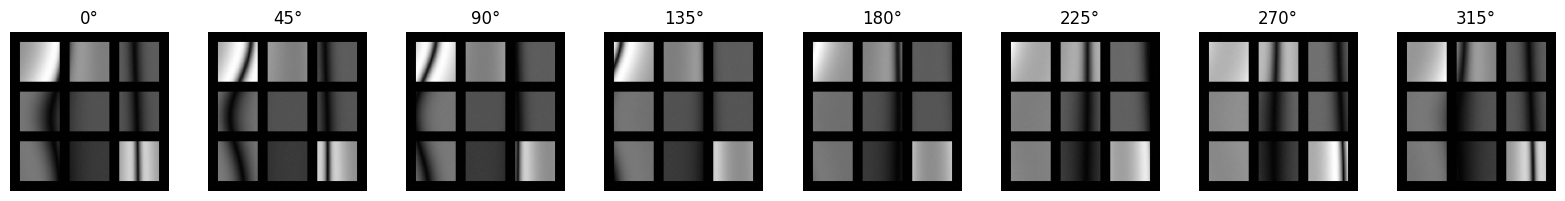

In [29]:
data = dataset['M']
print(f"Data shape: {data.shape}")

# Visualize dataset
deepssfp.visualize_images(
    input_images=data,
    num_samples=1,
    labels=['0\u00b0', '45\u00b0', '90\u00b0', '135\u00b0', '180\u00b0', '225\u00b0', '270\u00b0', '315\u00b0'],
)

(1024, 8)


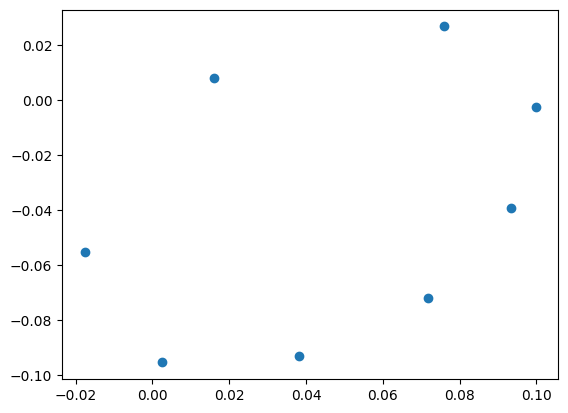

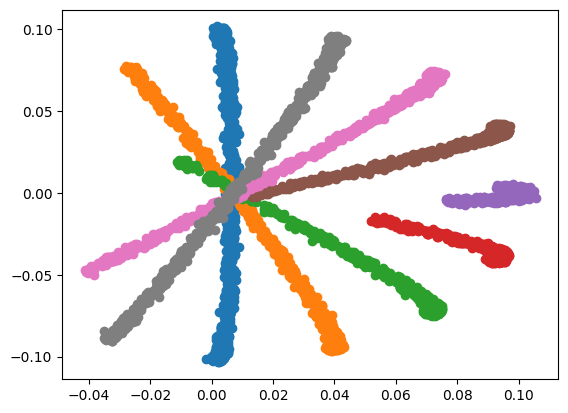

In [30]:
dataset['seg'].shape
seg1 = dataset['seg'] == 6
points = dataset['M'][0][seg1]
print(points.shape)

idx=120
plt.scatter(np.real(points[idx,:]), np.imag(points[idx,:]))
plt.show()

plt.scatter(np.real(points[:,0]), np.imag(points[:,0]))
plt.scatter(np.real(points[:,1]), np.imag(points[:,1]))
plt.scatter(np.real(points[:,2]), np.imag(points[:,2]))
plt.scatter(np.real(points[:,3]), np.imag(points[:,3]))
plt.scatter(np.real(points[:,4]), np.imag(points[:,4]))
plt.scatter(np.real(points[:,5]), np.imag(points[:,5]))
plt.scatter(np.real(points[:,6]), np.imag(points[:,6]))
plt.scatter(np.real(points[:,7]), np.imag(points[:,7]))
plt.show()

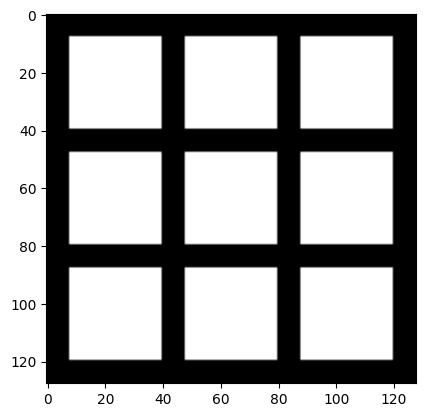

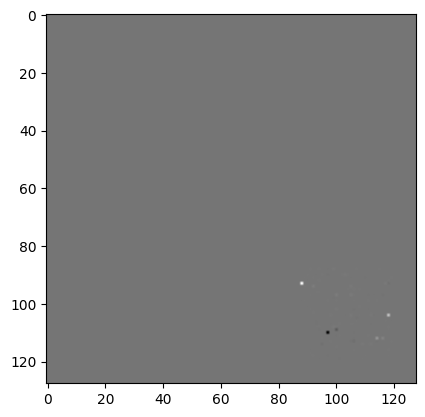

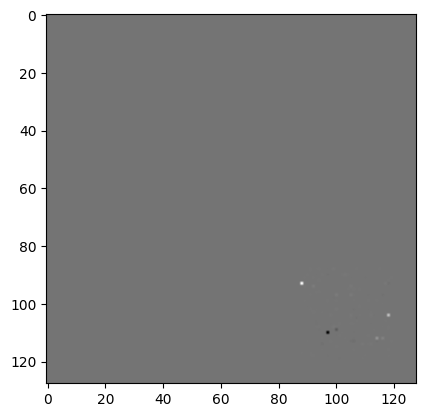

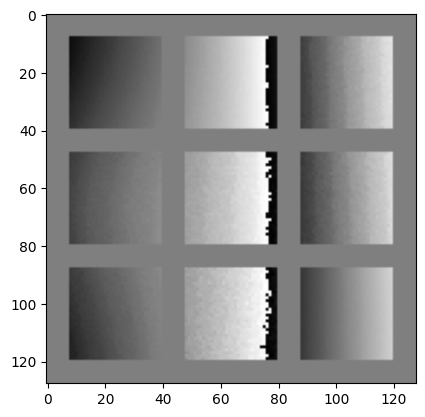

In [42]:
from skimage.filters import threshold_li

M = dataset['M']
M = np.squeeze(M)
M = np.transpose(M, (2,0,1))
alpha = np.deg2rad(22)
TR = 3e-3

M.shape
csum = np.sqrt(np.sum(np.abs(M)**2, axis=0))
mask = csum > threshold_li(csum)
plt.imshow(mask, cmap='gray')
plt.show()

_, T1est, T2est, dfest = mssfp.planet(M, alpha, TR, mask=mask, pc_axis=0)
plt.imshow(T1est, cmap='gray')
plt.show()
plt.imshow(T2est, cmap='gray')
plt.show()
plt.imshow(dfest, cmap='gray')
plt.show()